# 👋 Welcome to the introduction tutorial

In this tutorial, we will guide you, while using *puncc*, throughout the process of uncertainty quantification in a classification task. By the end of this notebook, you will be able to wrap your own models into conformal predictors and analyze their performance.

**Table of contents**

- [📊 Conformal Classification](#cc)
    - [💾 MNIST Dataset](#cc-data)
    - [🔮 Predicton Model](#cc-pm)
    - [⚙️ Conformal Prediction](#cc-cp)

**Links**
- [<img src="https://github.githubassets.com/images/icons/emoji/octocat.png" width=20> Github](https://github.com/deel-ai/puncc)
- [📘 Documentation](https://deel-ai.github.io/puncc/index.html)

In [1]:
from deel.puncc.config import set_backend

set_backend("tensorflow")

## 📊 Conformal Classification <a class="anchor" id="cc"></a>

Let’s tackle the classic problem of [MNIST handwritten digits](https://en.wikipedia.org/wiki/MNIST_database) classification. The goal is to evaluate through conformal prediction the uncertainty associated with a predictive classifier.

### 💾 MNIST Dataset <a class="anchor" id="cc-data"></a>

MNIST dataset contains a large number of $28\times28$ digit images to which are associated digit labels. As the data generating process is considered i.i.d (check [this post](https://newsletter.altdeep.ai/p/the-story-of-mnist-and-the-perils)), conformal prediction is applicable 👏.

We split the data into three subsets:

* Fit subset ${\cal D_{fit}}$ to train the model.
* Calibration subset ${\cal D_{calib}}$ on which nonconformity scores are computed.
* Test subset ${\cal D_{test}}$ on which the prediction sets are estimated.

---
**NOTE**

   Rigorously, for the probabilistic guarantee to hold, the calibration subset
   needs to be resampled for each new example in the test set.

---


In addition to data preprocessing, the following code implements the aforementioned steps:

In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST Database
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocessing: reshaping and standardization
X_train = X_train.reshape((len(X_train), 28, 28))
X_train = X_train.astype('float32') / 255
X_test = X_test.reshape((len(X_test), 28 , 28))
X_test = X_test.astype('float32') / 255

# Split fit and calib datasets
X_fit, X_calib  = X_train[:50000], X_train[50000:]
y_fit, y_calib  = y_train[:50000], y_train[50000:]

# One hot encoding of classes
y_fit_cat = to_categorical(y_fit)
y_calib_cat = to_categorical(y_calib)
y_test_cat = to_categorical(y_test)

2026-03-24 11:00:20.168240: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 11:00:21.020301: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### 🔮 Prediction model <a class="anchor" id="cc-pm"></a>

We consider a convnet defined as follows:

In [ ]:
from tensorflow import random
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

random.set_seed(0)
keras.utils.set_random_seed(0)

# Classification model: convnet composed of two convolution/pooling layers
# and a dense output layer
class_predictor = keras.Sequential(
   [
      keras.Input(shape=(28, 28, 1)),
      layers.Conv2D(16, kernel_size=(3, 3), activation="relu"),
      layers.MaxPooling2D(pool_size=(2, 2)),
      layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
      layers.MaxPooling2D(pool_size=(2, 2)),
      layers.Flatten(),
      layers.Dense(10, activation="softmax"),
   ]
)

2026-03-24 11:00:29.574340: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


For the convnet above, we use `deel.puncc.api.prediction.BasePredictor` as wrapper. Note that our model is not already trained (`is_trained = False`), we need to provide the compilation config to the constructor:

In [4]:
# The compilation details are gathered in a dictionnary
compile_kwargs = {"optimizer":"adam", "loss":"categorical_crossentropy","metrics":["accuracy"]}
class_predictor.compile(**compile_kwargs)

### ⚙️ Conformal Prediction <a class="anchor" id="cc-cp"></a>

The RAPS procedure is chosen to conformalize our convnet classifier. Such algorithm has two hyparameters $\lambda$ and $k_{reg}$ that encourage smaller prediction sets.

To start off gently, we will ignore the regularization term ($\lambda=0$), which simply turns the procedure into APS:

In [ ]:
from deel.puncc.classification import RAPS

# Coverage target is 1-alpha = 90%
alpha = .1

# Instanciate the RAPS wrapper around the convnet predictor.
# The `train` argument is set to True such that the convnet model is trained
# before the calibration. You can initialize it to False if the model is
# already trained and you want to save time.
aps_cp = RAPS(class_predictor, lambd=0)

# The train details of the convnet are gathered in a dictionnary
fit_kwargs = {"epochs":2, "batch_size":256, "validation_split": .1, "verbose":1}

# Train model (argument `train` is True) on the fitting dataset (w.r.t. the fit config)
# and compute the residuals on the calibration dataset.
aps_cp.fit(X_fit, y_fit_cat, **fit_kwargs)
aps_cp.calibrate(X_calib, y_calib)

# The `predict` returns the output of the convnet model `y_pred` and
# the calibrated prediction set `set_pred`.
y_pred, set_pred = aps_cp.predict(X_test, alpha=alpha)

Epoch 1/2


2026-03-24 11:00:33.709288: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8305 - loss: 0.6486 - val_accuracy: 0.9202 - val_loss: 0.2570
Epoch 2/2
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9453 - loss: 0.1856 - val_accuracy: 0.9476 - val_loss: 0.1686


Let's visualize an example of point prediction and set prediction.

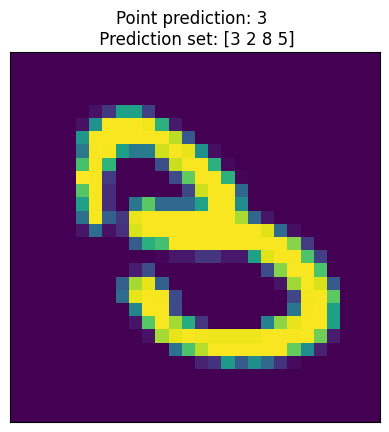

In [6]:
import matplotlib.pyplot as plt
import numpy as np

sample = 18

plt.imshow(X_test[sample].reshape((28,28)))
_ = plt.title(f"Point prediction: {np.argmax(y_pred[sample])} \n Prediction set: {set_pred[sample]}")
_ = plt.xticks([])
_ = plt.yticks([])

Our library provides several metrics in `deel.puncc.metrics` to evaluate the conformalization procedure. Below, we compute the average empirical coverage and the average empirical size of the prediction sets on the test examples:

In [7]:
from deel.puncc import metrics

mean_coverage = metrics.classification_mean_coverage(y_test, set_pred)
mean_size = metrics.classification_mean_size(set_pred)

print(f"Empirical coverage : {mean_coverage:.2f}")
print(f"Average set size : {mean_size:.2f}")

Empirical coverage : 0.99
Average set size : 1.20


# 🎉 Congratulations
**You are now familiar with basics of conformal prediction with puncc !**

To go further, check the [**API tutorial**](api_intro.ipynb) to build your own conformal prediction algorithms !